# Heston: QE simulation, Fourier pricing, smile and calibration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mcengine.reporting.style import apply_style, PALETTE

apply_style()
%matplotlib inline

In [2]:
from mcengine.models import Heston
from mcengine import EuropeanOption, price_mc
from mcengine.engines.fourier import gil_pelaez_price, carr_madan_prices, fourier_prices
from mcengine.volatility import implied_vol

h = Heston(s0=100.0, r=0.03, v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7)
print("Feller ratio:", round(h.feller_ratio, 3))
gp = gil_pelaez_price(h, 100.0, 1.0)
print("Gil-Pelaez:", gp, " Carr-Madan:", carr_madan_prices(h, [100.0], 1.0)[0])
for scheme in ("qe", "euler"):
    res = price_mc(
        h.with_scheme(scheme), EuropeanOption(100.0, 1.0), n_paths=100_000, n_steps=50, seed=1
    )
    print(scheme, res, f"error {res.error_in_se(gp):+.2f} SE")

Feller ratio: 0.64
Gil-Pelaez: 8.92941045360216  Carr-Madan: 8.929410453602205


qe mc-plain: 8.904355 +/- 0.032674 (95% CI [8.840316, 8.968393], n=100000) error -0.77 SE


euler mc-plain: 8.913552 +/- 0.032809 (95% CI [8.849247, 8.977856], n=100000) error -0.48 SE


## Implied-volatility smile across maturities

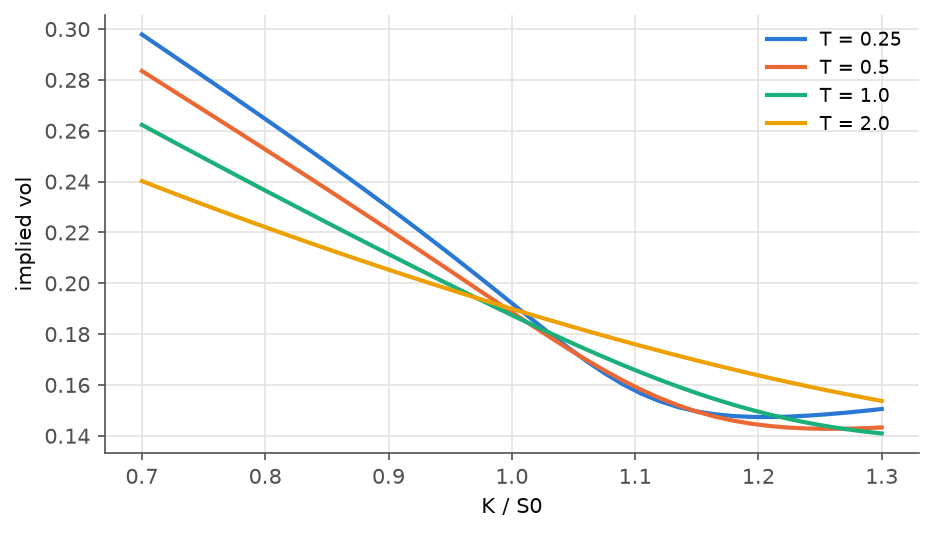

In [3]:
m = np.linspace(0.7, 1.3, 41)
fig, ax = plt.subplots(figsize=(7, 3.8))
for i, t in enumerate((0.25, 0.5, 1.0, 2.0)):
    vols = implied_vol(fourier_prices(h, 100 * m, t), 100.0, 100 * m, t, h.r)
    ax.plot(m, vols, color=PALETTE[i], label=f"T = {t}")
ax.set_xlabel("K / S0")
ax.set_ylabel("implied vol")
ax.legend();

## Calibration to a noisy synthetic surface

In [4]:
from mcengine.calibration import synthetic_surface, calibrate_heston

true = Heston(100.0, 0.02, 0.04, 1.5, 0.05, 0.6, -0.7)
surface = synthetic_surface(true, noise_vol=0.001, seed=1)
fit = calibrate_heston(surface, seed=0)
for name, value in fit.params.items():
    print(f"{name:6s} true {getattr(true, name):+.4f}   fitted {value:+.4f}")
print(f"RMSE {fit.rmse_vol * 1e4:.2f} bp, Feller ratio {fit.feller_ratio:.3f}")

v0     true +0.0400   fitted +0.0400
kappa  true +1.5000   fitted +1.5337
theta  true +0.0500   fitted +0.0500
xi     true +0.6000   fitted +0.6070
rho    true -0.7000   fitted -0.6997
RMSE 9.22 bp, Feller ratio 0.416
